# Importing libraries and setting up the environment

In [9]:
#Cell 1:Library Imports
import os
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from accelerate import Accelerator
import matplotlib.pyplot as plt
import numpy as np
import gradio as gr
from torchvision.utils import make_grid
from PIL import Image
#Setting up random seeds for reproducibility
torch.manual_seed(1)
np.random.seed(1)

# Data before Preprocessing

Repo card metadata block was not found. Setting CardData to empty.


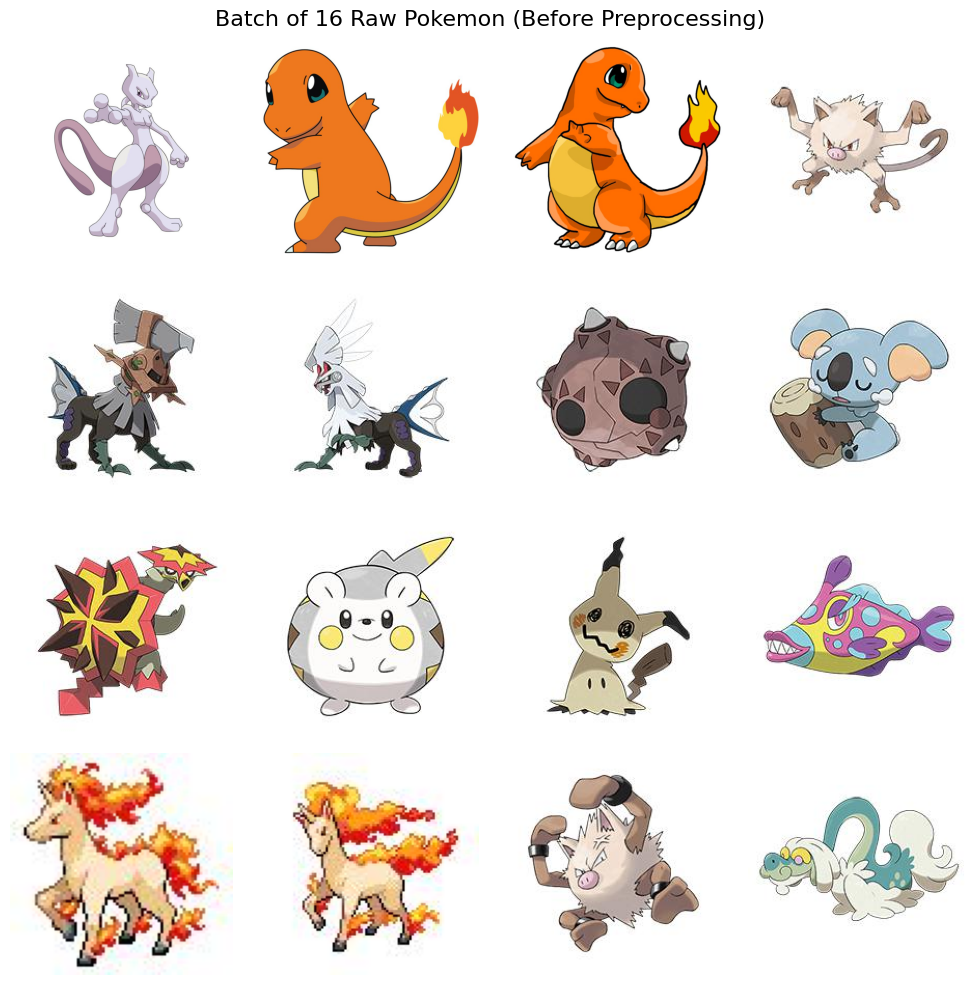

In [10]:
import matplotlib.pyplot as plt
from datasets import load_dataset
dataset = load_dataset("huggan/pokemon", split="train")
#Temporarily bypassing the preprocessing pipeline to get the raw images
raw_dataset = dataset.with_transform(None)
#Creating a 4x4 grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
#Flattening the 4x4 grid into a simple 1D list
axes = axes.flatten()
#Looping 16 times to grab the first 16 images and plot them
for i in range(16):
    raw_image = dataset[i]["image"]
    axes[i].imshow(raw_image)
    axes[i].axis("off")
#Adding a main title and adjusting spacing so things don't overlap
plt.suptitle("Batch of 16 Raw Pokemon (Before Preprocessing)", fontsize=16)
plt.tight_layout()
plt.show()

# Preprocessing

Repo card metadata block was not found. Setting CardData to empty.


--- Inspecting Data Augmentations ---


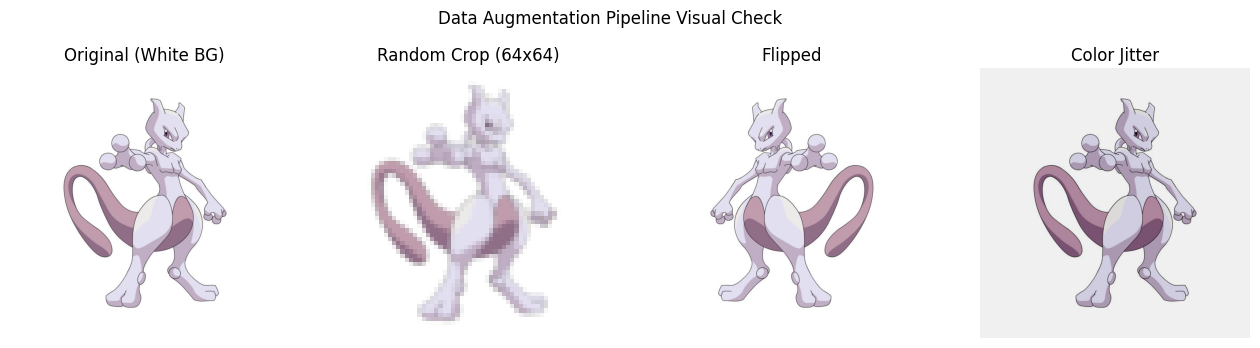

--- Configuring Full Data Pipeline ---
Dataset ready. Total batches per epoch: 459


In [11]:
#Cell 2:Loading Dataset,Standardizing Backgrounds,and Augmentations
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
print("Downloading the huggan/pokemon dataset...")
dataset = load_dataset("huggan/pokemon", split="train")
#Standardizing Transparent Backgrounds to Pure White for the uniformity
def add_white_background(image):
    if image.mode == 'RGBA':
        #Creating a solid white background of the same size
        background = Image.new('RGBA', image.size, (255, 255, 255))
        #Pasting the Pokemon over the white background using its own alpha channel as a mask
        background.paste(image, mask=image.split()[3]) 
        return background.convert('RGB')
    return image.convert('RGB')
print("--- Inspecting Data Augmentations ---")
#1.Grabbing a raw PIL image and applying the white background fix
original_image = add_white_background(dataset[0]["image"])
#2.Defining individual transforms
resize_larger = transforms.Resize((72, 72))
crop_transform = transforms.RandomCrop(64)
#3.Applying the transforms step-by-step
larger_image = resize_larger(original_image)
cropped_image = crop_transform(larger_image)
flipped_image = transforms.RandomHorizontalFlip(p=1.0)(original_image) # Set to 1.0 just for plotting
jittered_image = transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)(original_image)
#4.Plotting them side-by-side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(original_image)
axes[0].set_title("Original (White BG)")
axes[0].axis("off")

axes[1].imshow(cropped_image)
axes[1].set_title("Random Crop (64x64)")
axes[1].axis("off")

axes[2].imshow(flipped_image)
axes[2].set_title("Flipped")
axes[2].axis("off")

axes[3].imshow(jittered_image)
axes[3].set_title("Color Jitter")
axes[3].axis("off")
plt.suptitle("Data Augmentation Pipeline Visual Check")
plt.show()
print("--- Configuring Full Data Pipeline ---")
#5.Prepare the full preprocessing pipeline for actual training
image_size = 64
train_batch_size = 16 
preprocess = transforms.Compose([
    transforms.Resize((72, 72)), 
    transforms.RandomCrop(image_size), 
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ColorJitter(brightness=0.5, contrast=0.2, saturation=0.2, hue=0.1), 
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) 
])
#Applying the white background fix inside the lambda function before preprocessing
dataset.set_transform(lambda examples: {"images": [preprocess(add_white_background(img)) for img in examples["image"]]})
dataloader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True, drop_last=True)
print(f"Dataset ready. Total batches per epoch: {len(dataloader)}")

# Visual Representaion and Data Exploration

--- Initiating Data Inspection ---
Batch Tensor Shape: torch.Size([16, 3, 64, 64]) -> (Batch, Channels, Height, Width)
Tensor Data Type: torch.float32
Pixel Value Range: Min = -1.0000, Max = 1.0000


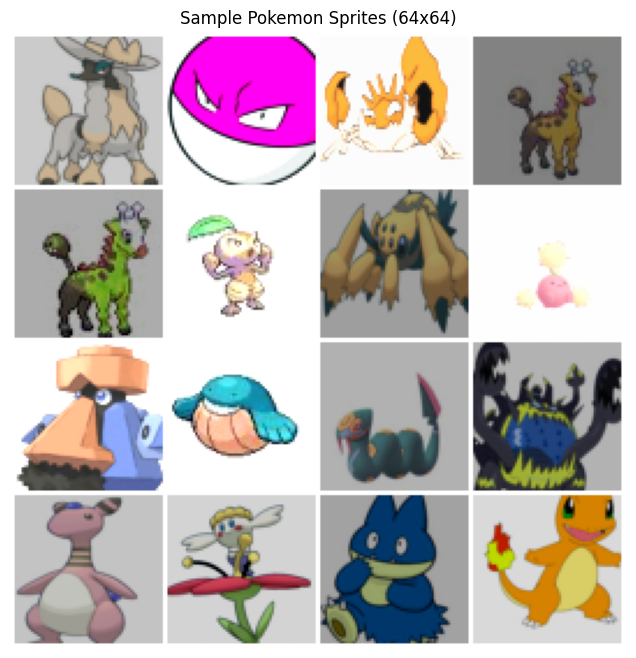

In [12]:
from torchvision.utils import make_grid
#Cell 3:Data Exploration & Visual Inspection
print("--- Initiating Data Inspection ---")
#1.Grabbing a single batch procedurally
data_iterator = iter(dataloader)
batch = next(data_iterator)
images = batch["images"]
#2.Inspecting shapes and data types
print(f"Batch Tensor Shape: {images.shape} -> (Batch, Channels, Height, Width)")
print(f"Tensor Data Type: {images.dtype}")
#3.Inspecting pixel value ranges
min_val, max_val = images.min().item(), images.max().item()
print(f"Pixel Value Range: Min = {min_val:.4f}, Max = {max_val:.4f}")
#4.Visualizing Inspection of the Pokemon Sprites
#Convert from [-1, 1] to [0, 1] for matplotlib
viewable_images = (images + 1.0) / 2.0
viewable_images = viewable_images.clamp(0.0, 1.0)
grid = make_grid(viewable_images, nrow=4, padding=2, pad_value=1.0)
grid_np = grid.permute(1, 2, 0).numpy()
plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.title("Sample Pokemon Sprites (64x64)")
plt.axis('off')
plt.show()

# Normalization of the pixel values for the U-Net

--- Checking Mathematical Shifting of Pixels ---


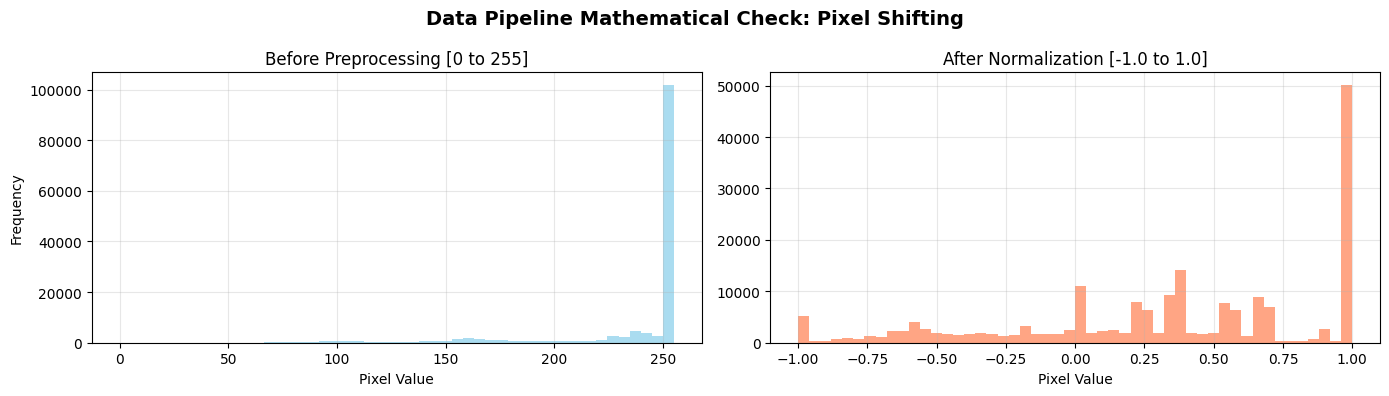

In [14]:
print("--- Checking Mathematical Shifting of Pixels ---")
#1.Convert the original raw PIL Image directly into a numpy array to get the true 0-255 values
unnormalized_pixels = np.array(raw_image).flatten()
#Grab the final normalized tensor (usually in the [-1.0, 1.0] range)
normalized_pixels = images.numpy().flatten()
#2.Plotting them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#Graph A: True Raw Pixels (0 to 255)
axes[0].hist(unnormalized_pixels, bins=50, color='skyblue', alpha=0.7)
axes[0].set_title("Before Preprocessing [0 to 255]", fontsize=12)
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)
#Graph B: After Normalization (-1.0 to 1.0)
axes[1].hist(normalized_pixels, bins=50, color='coral', alpha=0.7)
axes[1].set_title("After Normalization [-1.0 to 1.0]", fontsize=12)
axes[1].set_xlabel("Pixel Value")
axes[1].grid(True, alpha=0.3)
plt.suptitle("Data Pipeline Mathematical Check: Pixel Shifting", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Adding noise to the real images

--- Visualizing Forward Noise Process ---


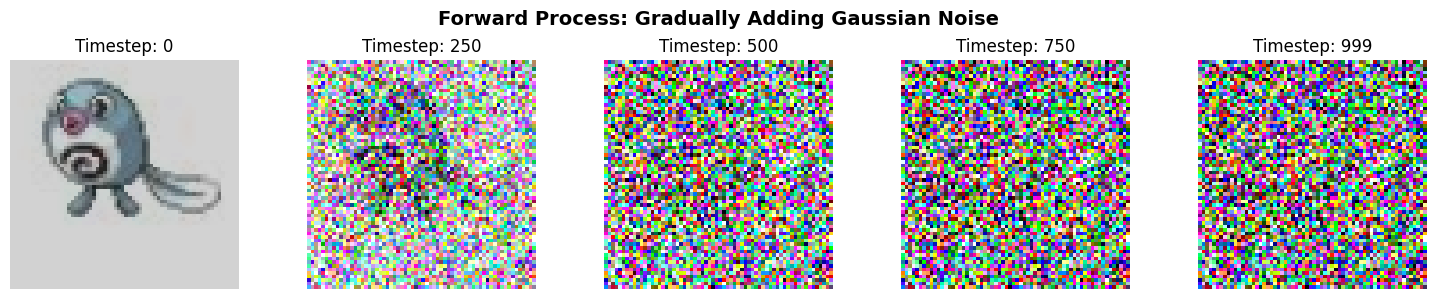

In [25]:
#Cell 3-2:Visualizing the Forward Diffusion Process (Adding Noise)
import matplotlib.pyplot as plt
from diffusers import DDPMScheduler
print("--- Visualizing Forward Noise Process ---")
#Grabbing one clean image from the dataloader
sample_batch = next(iter(dataloader))
clean_image = sample_batch["images"][0].unsqueeze(0) # Shape: (1, 3, 64, 64)
#Initializing a standard scheduler just for this visualization
visual_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
noise = torch.randn(clean_image.shape)
#Defining the timesteps for snapshot
timesteps_to_show = [0, 250, 500, 750, 999]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, t in enumerate(timesteps_to_show):
    if t == 0:
        noisy_image = clean_image
    else:
        #Mathematically inject noise for timestep 't'
        t_tensor = torch.tensor([t], dtype=torch.long)
        noisy_image = visual_scheduler.add_noise(clean_image, noise, t_tensor)
    #Converting back to viewable image [0, 1]
    plot_img = ((noisy_image[0] + 1.0) / 2.0).clamp(0.0, 1.0).permute(1, 2, 0).numpy()
    axes[i].imshow(plot_img)
    axes[i].set_title(f"Timestep: {t}")
    axes[i].axis("off")
plt.suptitle("Forward Process: Gradually Adding Gaussian Noise", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Cell-4:Defining Model-A and it's training

In [29]:
#MODEL A:UNET with Fast EMA & Low Timesteps may get more FID score than thought
import torch
import torch.nn.functional as F
from accelerate import Accelerator
from tqdm.auto import tqdm
from diffusers import UNet2DModel, DDPMScheduler
from diffusers.training_utils import EMAModel
print("--- Configuring Model A ---")
num_timesteps_A = 100
ema_decay_rate_A = 0.999
beta_schedule_type_A = "linear"
epochs = 50
weight_dtype = torch.float32
print('Number of timesteps: ',num_timesteps_A)
print('EMA Decay rate: ',ema_decay_rate_A)
print('Beta Schedule: ',beta_schedule_type_A)
print('Number of epochs: ',epochs)
#1.Initializing UNet A
model_A = UNet2DModel(
    sample_size=64,  
    in_channels=3,
    out_channels=3,
    layers_per_block=2,  
    block_out_channels=(64, 128, 128, 256),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
)
#2.Initializing Scheduler A & EMA A
noise_scheduler_A = DDPMScheduler(num_train_timesteps=num_timesteps_A, beta_schedule=beta_schedule_type_A)
ema_model_A = EMAModel(model_A.parameters(), decay=ema_decay_rate_A)
#3.Hardware Optimization
accelerator_A = Accelerator(gradient_accumulation_steps=4, mixed_precision="no")
model_A.to(dtype=weight_dtype)
ema_model_A.to(dtype=weight_dtype)
#4.Setup Optimizer
optimizer_A = torch.optim.AdamW(model_A.parameters(), lr=1e-4)
model_A, optimizer_A, dataloader_A = accelerator_A.prepare(model_A, optimizer_A,dataloader)
ema_model_A.to(accelerator_A.device)

--- Configuring Model A ---
Number of timesteps:  100
EMA Decay rate:  0.999
Beta Schedule:  linear
Number of epochs:  50


In [30]:
#Training Loop A
loss_history_A = []
print(f"\n--- Training Model A on device: {accelerator_A.device} for {epochs} epochs ---")
global_step_A = 0
for epoch in range(epochs):
    model_A.train()
    epoch_loss_A = 0.0
    progress_bar_A = tqdm(dataloader_A, desc=f"Model A Epoch {epoch+1}/{epochs}")   
    for step, batch in enumerate(progress_bar_A):
        clean_images = batch["images"].to(dtype=weight_dtype, device=accelerator_A.device)
        batch_size = clean_images.shape[0]
        noise = torch.randn(clean_images.shape, dtype=weight_dtype, device=accelerator_A.device)
        #Using the 100-timestep scheduler limit
        timesteps = torch.randint(0, noise_scheduler_A.config.num_train_timesteps, (batch_size,), device=accelerator_A.device, dtype=torch.int64)
        noisy_images = noise_scheduler_A.add_noise(clean_images, noise, timesteps)
        with accelerator_A.accumulate(model_A):
            #Pure UNet forward pass
            noise_pred = model_A(noisy_images, timesteps, return_dict=False)[0]
            loss = F.mse_loss(noise_pred, noise)           
            accelerator_A.backward(loss)            
            if accelerator_A.sync_gradients:
                accelerator_A.clip_grad_norm_(model_A.parameters(), 1.0)            
            optimizer_A.step()
            optimizer_A.zero_grad()            
        if accelerator_A.sync_gradients:
            ema_model_A.step(model_A.parameters())
            global_step_A += 1
        epoch_loss_A += loss.item()
        progress_bar_A.set_postfix(step_loss=loss.item())
    loss_history_A.append(epoch_loss_A / len(dataloader_A))
print("Model A (100 Timesteps) Training Complete!")


--- Training Model A on device: mps for 50 epochs ---


Model A Epoch 50/50: 100%|██████████| 459/459 [03:24<00:00,  2.24it/s, step_loss=0.034] 

Model A (100 Timesteps) Training Complete!


# Cell-5:Defining Model-B and it's training

In [31]:
#MODEL B:UNET with Standard EMA, High Timesteps, and Cosine Schedule
import torch.nn.functional as F
from accelerate import Accelerator
from tqdm.auto import tqdm
from diffusers import UNet2DModel, DDPMScheduler
from diffusers.training_utils import EMAModel
print("--- Configuring Model B ---")
num_timesteps_B = 1000
ema_decay_rate_B = 0.9999
beta_schedule_type_B = "squaredcos_cap_v2"#The exact string for cosine schedule
epochs = 50
weight_dtype = torch.float32
print('Number of timesteps: ', num_timesteps_B)
print('EMA Decay rate: ', ema_decay_rate_B)
print('Beta Schedule: ', beta_schedule_type_B)
print('Number of epochs: ', epochs)
#1.Initializing UNet B
model_B = UNet2DModel(
    sample_size=64,  
    in_channels=3,
    out_channels=3,
    layers_per_block=2,  
    block_out_channels=(64, 128, 128, 256),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
)
#2.Initializing Scheduler B & EMA B
noise_scheduler_B = DDPMScheduler(num_train_timesteps=num_timesteps_B, beta_schedule=beta_schedule_type_B)
ema_model_B = EMAModel(model_B.parameters(), decay=ema_decay_rate_B)
#3.Hardware Optimization (Mac MPS Fix is applied)
accelerator_B = Accelerator(gradient_accumulation_steps=4, mixed_precision="no")
model_B.to(dtype=weight_dtype)
ema_model_B.to(dtype=weight_dtype)
#4.Setup Optimizer
optimizer_B = torch.optim.AdamW(model_B.parameters(), lr=1e-4)
model_B, optimizer_B, dataloader_B = accelerator_B.prepare(model_B, optimizer_B, dataloader)
ema_model_B.to(accelerator_B.device)

--- Configuring Model B ---
Number of timesteps:  1000
EMA Decay rate:  0.9999
Beta Schedule:  squaredcos_cap_v2
Number of epochs:  50


In [32]:
#Training Loop B
loss_history_B= []
print(f"\n--- Training Model B on device: {accelerator_B.device} for {epochs} epochs ---")
global_step_B = 0
for epoch in range(epochs):
    model_B.train()
    epoch_loss_B = 0.0
    progress_bar_B = tqdm(dataloader_B, desc=f"Model B Epoch {epoch+1}/{epochs}")    
    for step, batch in enumerate(progress_bar_B):
        clean_images = batch["images"].to(dtype=weight_dtype, device=accelerator_B.device)
        batch_size = clean_images.shape[0]        
        noise = torch.randn(clean_images.shape, dtype=weight_dtype, device=accelerator_B.device)
        #Grabbing timesteps specifically using Model B's 1000-step scheduler
        timesteps = torch.randint(0, noise_scheduler_B.config.num_train_timesteps, (batch_size,), device=accelerator_B.device, dtype=torch.int64)
        noisy_images = noise_scheduler_B.add_noise(clean_images, noise, timesteps)
        with accelerator_B.accumulate(model_B):
            noise_pred = model_B(noisy_images, timesteps, return_dict=False)[0]
            loss = F.mse_loss(noise_pred, noise)            
            accelerator_B.backward(loss)            
            if accelerator_B.sync_gradients:
                accelerator_B.clip_grad_norm_(model_B.parameters(), 1.0)           
            optimizer_B.step()
            optimizer_B.zero_grad()            
        if accelerator_B.sync_gradients:
            ema_model_B.step(model_B.parameters())
            global_step_B += 1
        epoch_loss_B += loss.item()
        progress_bar_B.set_postfix(step_loss=loss.item())
    loss_history_B.append(epoch_loss_B / len(dataloader_B))
print("Model B (1000 Timesteps, Cosine Schedule) Training Complete!")


--- Training Model B on device: mps for 50 epochs ---


Model B Epoch 50/50: 100%|██████████| 459/459 [03:19<00:00,  2.31it/s, step_loss=0.0292]

Model B (1000 Timesteps, Cosine Schedule) Training Complete!


# Loss Comparison between the models

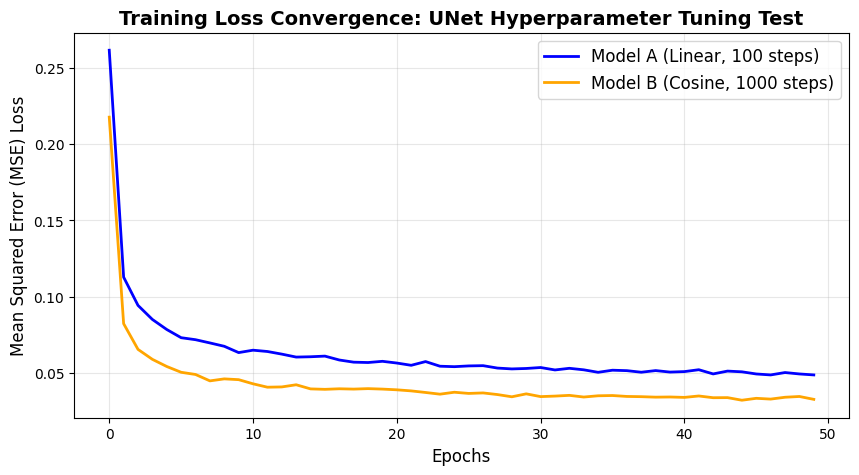

In [33]:
# Cell 5-1: Training Loss Convergence Comparison
plt.figure(figsize=(10, 5))
plt.plot(loss_history_A, label='Model A (Linear, 100 steps)', color='blue', linewidth=2)
plt.plot(loss_history_B, label='Model B (Cosine, 1000 steps)', color='orange', linewidth=2)
plt.title("Training Loss Convergence: UNet Hyperparameter Tuning Test", fontsize=14, fontweight="bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Mean Squared Error (MSE) Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Evauation Metric

--- Initiating Test Evaluation ---
Extracting real images...

Generating fake images from Model A (100 Timesteps)...


Model A Denoising: 100%|██████████| 100/100 [00:17<00:00,  5.67it/s]



Generating fake images from Model B (1000 Timesteps)...


Model B Denoising: 100%|██████████| 1000/1000 [02:46<00:00,  6.00it/s]



Calculating final FID distances on CPU...
Model A Final FID: 11.27
Model B Final FID: 17.04


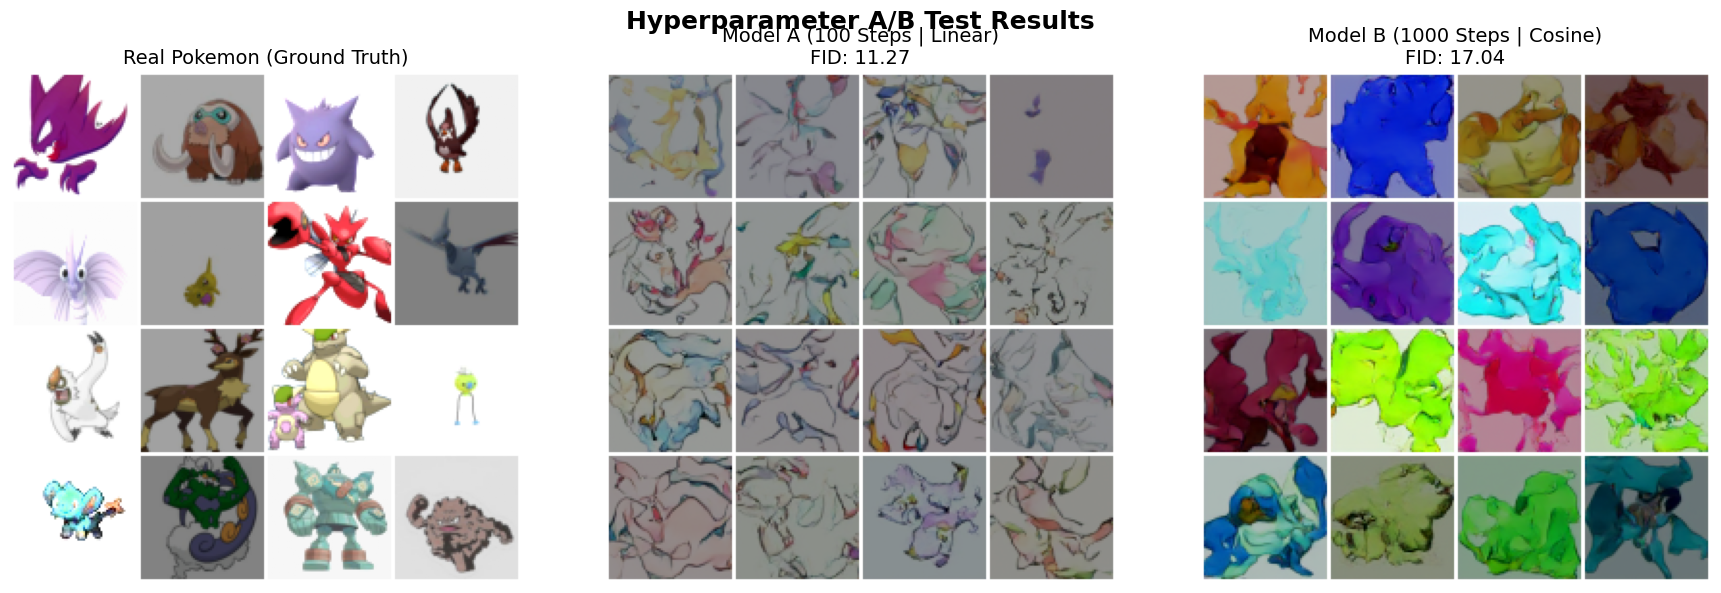

In [36]:
#Cell 6:Visual Comparison and FID Score Calculation(A vs B)
from torchmetrics.image.fid import FrechetInceptionDistance
from tqdm.auto import tqdm
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
print("--- Initiating Test Evaluation ---")
#1.Transfer EMA weights back to main models for best quality
ema_model_A.copy_to(model_A.parameters())
model_A.eval()
model_A.to(torch.float32) #Converting Model A to safe 32-bit math
ema_model_B.copy_to(model_B.parameters())
model_B.eval()
model_B.to(torch.float32) #Converting Model B to safe 32-bit math
#2.Initializing two separate FID Metrics on the CPU
fid_metric_A = FrechetInceptionDistance(feature=64)
fid_metric_B = FrechetInceptionDistance(feature=64)
#3.Process REAL Images
print("Extracting real images...")
data_iterator = iter(dataloader) #dataloader_A / dataloader_B # or dataloader_A / dataloader_B
real_batch = next(data_iterator)["images"]
batch_size_gen = real_batch.shape[0] 
image_shape = (batch_size_gen, 3, 64, 64)
#Converting for FID (UInt8) and Plotting (Float32)
real_images_uint8 = ((real_batch + 1.0) / 2.0 * 255).clamp(0, 255).to(torch.uint8)
real_images_plot = ((real_batch[:16] + 1.0) / 2.0).clamp(0.0, 1.0).cpu().to(torch.float32) 
#Giving the real images to both FID calculators
fid_metric_A.update(real_images_uint8.cpu(), real=True)
fid_metric_B.update(real_images_uint8.cpu(), real=True)
#4.Generating FAKE Images (Model A)
print("\nGenerating fake images from Model A (100 Timesteps)...")
#Generate starting noise in float32
gen_images_A = torch.randn(image_shape, dtype=torch.float32, device=accelerator_A.device)
noise_scheduler_A.set_timesteps(100) # Inference steps
for t in tqdm(noise_scheduler_A.timesteps, desc="Model A Denoising"):
    with torch.no_grad():
        residual = model_A(gen_images_A, t, return_dict=False)[0]
    gen_images_A = noise_scheduler_A.step(residual, t, gen_images_A).prev_sample
fake_A_uint8 = ((gen_images_A + 1.0) / 2.0 * 255).clamp(0, 255).to(torch.uint8)
fake_A_plot = ((gen_images_A[:16] + 1.0) / 2.0).clamp(0.0, 1.0).cpu().to(torch.float32)
fid_metric_A.update(fake_A_uint8.cpu(), real=False)
#5.Generate FAKE Images (Model B)
print("\nGenerating fake images from Model B (1000 Timesteps)...")
#Generate starting noise in float32
gen_images_B = torch.randn(image_shape, dtype=torch.float32, device=accelerator_B.device)
noise_scheduler_B.set_timesteps(1000) 
for t in tqdm(noise_scheduler_B.timesteps, desc="Model B Denoising"):
    with torch.no_grad():
        residual = model_B(gen_images_B, t, return_dict=False)[0]
    gen_images_B = noise_scheduler_B.step(residual, t, gen_images_B).prev_sample
fake_B_uint8 = ((gen_images_B + 1.0) / 2.0 * 255).clamp(0, 255).to(torch.uint8)
fake_B_plot = ((gen_images_B[:16] + 1.0) / 2.0).clamp(0.0, 1.0).cpu().to(torch.float32)
fid_metric_B.update(fake_B_uint8.cpu(), real=False)
#6.Compute Scores and Plot Visuals
print("\nCalculating final FID distances on CPU...")
score_A = fid_metric_A.compute().item()
score_B = fid_metric_B.compute().item()
print(f"Model A Final FID: {score_A:.2f}")
print(f"Model B Final FID: {score_B:.2f}")
#Creating visual grids
real_grid = make_grid(real_images_plot, nrow=4, padding=2, pad_value=1.0).permute(1, 2, 0).numpy()
fake_grid_A = make_grid(fake_A_plot, nrow=4, padding=2, pad_value=1.0).permute(1, 2, 0).numpy()
fake_grid_B = make_grid(fake_B_plot, nrow=4, padding=2, pad_value=1.0).permute(1, 2, 0).numpy()
#Plotting side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(real_grid)
axes[0].set_title("Real Pokemon (Ground Truth)", fontsize=14)
axes[0].axis("off")

axes[1].imshow(fake_grid_A)
axes[1].set_title(f"Model A (100 Steps | Linear)\nFID: {score_A:.2f}", fontsize=14)
axes[1].axis("off")

axes[2].imshow(fake_grid_B)
axes[2].set_title(f"Model B (1000 Steps | Cosine)\nFID: {score_B:.2f}", fontsize=14)
axes[2].axis("off")

plt.suptitle("Hyperparameter A/B Test Results", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

--- Visualizing Reverse Generation Process ---


Generating Evolution: 100%|██████████| 1000/1000 [00:18<00:00, 52.98it/s]


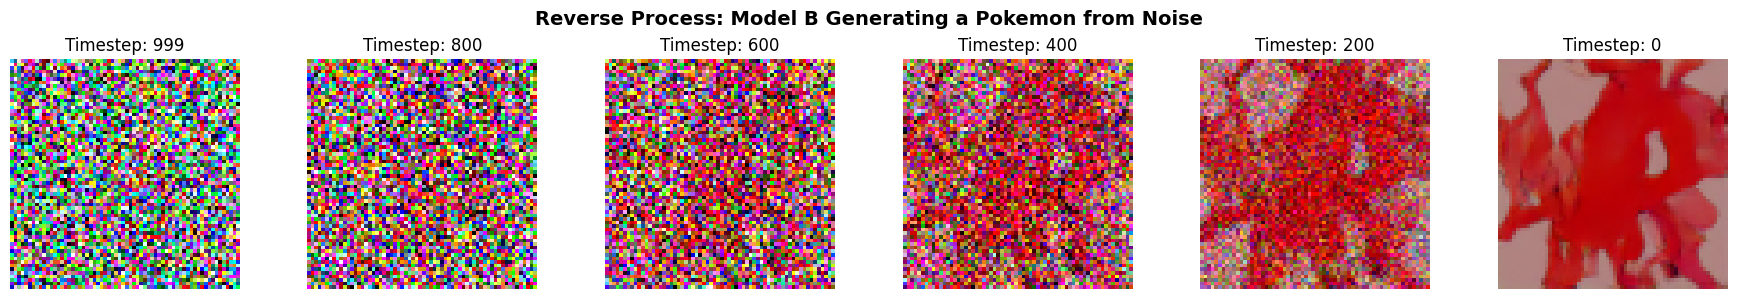

In [37]:
#Cell 7:Visualizing the Reverse Process (Model B Denoising)
print("--- Visualizing Reverse Generation Process ---")
#Using Model B since 1000 steps gives a smoother visual transition
model_B.eval()
model_B.to(torch.float32)
evolution_noise = torch.randn((1, 3, 64, 64), dtype=torch.float32, device=accelerator_B.device)
noise_scheduler_B.set_timesteps(1000)
snapshots = []
#Saving a snapshot at these specific timesteps as it counts down for the reconstruction of the image
capture_steps = [999, 800, 600, 400, 200, 0] 
for i, t in enumerate(tqdm(noise_scheduler_B.timesteps, desc="Generating Evolution")):
    with torch.no_grad():
        residual = model_B(evolution_noise, t, return_dict=False)[0]
    evolution_noise = noise_scheduler_B.step(residual, t, evolution_noise).prev_sample
    if t.item() in capture_steps or t.item() == 0:
        #Save a copy of the tensor for plotting
        img_copy = ((evolution_noise[0] + 1.0) / 2.0).clamp(0.0, 1.0).cpu().permute(1, 2, 0).numpy()
        snapshots.append((t.item(), img_copy))
#Plotting the evolution
fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 3))
for idx, (t_val, img) in enumerate(snapshots):
    axes[idx].imshow(img)
    axes[idx].set_title(f"Timestep: {t_val}")
    axes[idx].axis("off")
plt.suptitle("Reverse Process: Model B Generating a Pokemon from Noise", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [38]:
#Final Cell:Save Model A Weights for Production Deployment
import torch
#Command extracts the math from RAM and writes the binary file
torch.save(model_A.state_dict(), "model_A_weights.pth")
print("Model A weights successfully saved as a binary file!")

Model A weights successfully saved as a binary file!
